In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hashlib

def nd(arr):
    return np.asarray(arr).reshape(-1)

def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax

def short_hash(s: str) -> str:
    """Generate a 7-character hash from a given string."""
    return hashlib.sha256(s.encode()).hexdigest()[:7]

fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [32]:
from taln.taln_aln import (
    norm_text,
    tokenize,
    align_ng,
    align_lcs,
    align_difflib,
    reconstruct_target_by_idx,
    reconstruct_target_by_token,
)

In [33]:
# ablate target
import random

random.seed(3)


def ablate_custom(target): # ttype = "token"
    tokens, _ = tokenize(target, "whitespace")
    ablidx = random.randint(1, len(tokens) - 2)  # don't want it to be first or last token
    tokens.pop(ablidx)

    recon_ans = reconstruct_target_by_token("", tokens, " ")
    if target.startswith(" "): # and ttype == "token"
        recon_ans = " " + recon_ans

    return recon_ans, ablidx

In [34]:
ablate_custom("hello my name is sina")

('hello name is sina', 1)

In [35]:
cols = ["title", "question", "question_id", "is_impossible", "answer_type"]

In [ ]:
# load BOAT (pre-grouped)
tdf = pd.concat(
    [
        pd.read_json("../../data/boat_train.tdf.json", orient="records"),
        pd.read_json("../../data/boat_dev.tdf.json", orient="records"),
    ],
    ignore_index=True,
)
wdf = pd.concat(
    [
        pd.read_json("../../data/boat_train.wdf.json", orient="records"),
        pd.read_json("../../data/boat_dev.wdf.json", orient="records"),
    ],
    ignore_index=True,
)

# idx_start stored as JSON list -> convert back to set
tdf["idx_start"] = tdf["idx_start"].apply(set)
wdf["idx_start"] = wdf["idx_start"].apply(set)

# keep multi-token targets (whitespace words)
tdf = tdf[tdf["target"].str.split().str.len() > 2].reset_index(drop=True)

# align whitespace dataset rows to token dataset rows using (source, target.strip())
tdf["_key_target"] = tdf["target"].str.strip()
wdf["_key_target"] = wdf["target"].str.strip()

wdf = (
    wdf.set_index(["source", "_key_target"])
    .loc[tdf.set_index(["source", "_key_target"]).index]
    .reset_index()  # keep source/_key_target as columns
)

del tdf["_key_target"]
del wdf["_key_target"]

# stable IDs for pairing/debugging
tdf["hash_source"] = tdf["source"].apply(short_hash)
tdf["hash_target"] = tdf["target"].str.strip().apply(short_hash)
wdf["hash_source"] = tdf["hash_source"]
wdf["hash_target"] = tdf["hash_target"]

# ablate whitespace tokens (fair to whitespace)
tdf[["ablate_target", "ablate_idx"]] = tdf["target"].apply(ablate_custom).apply(pd.Series)
wdf[["ablate_target", "ablate_idx"]] = tdf[["ablate_target", "ablate_idx"]]

tdf = tdf.set_index(["hash_source", "hash_target"])
wdf = wdf.set_index(["hash_source", "hash_target"])

In [37]:
tdf.shape, wdf.shape

((5316, 5), (5316, 5))

In [38]:
"hello  my name is".split(' ')

['hello', '', 'my', 'name', 'is']

In [39]:
import time
# Apply function with timing
def timed_align(x, fn, ttype): # fn takes in source and target
    start_time = time.time()
    ctx = x["source"]
    tgt = x["ablate_target"]

    if ttype == "whitespace":
        tgt = tgt.strip()

    result = fn(ctx, tgt, ttype)
    end_time = time.time()

    # Calculate elapsed time in milliseconds
    t = (end_time - start_time) * 1000
    return result, t

def align_naive(ctx, tgt, ttype):
    # Return all contiguous occurrences as separate alignments.
    alns = []
    start = 0
    while True:
        idx = ctx.find(tgt, start)
        if idx < 0:
            break

        found = {
            "token": norm_text(tgt),
            "enc_token": -1,
            "start_idx": idx,
            "end_idx": idx + len(tgt),
        }
        alns.append([found])
        start = idx + 1

    return alns

methods = {
    "custom": align_ng,
    "lcs": align_lcs,
    "difflib": align_difflib,
    "naive": align_naive,
}



In [40]:
for m in methods:
    # alignments and time
    tdf[[f"{m}_aln", f"{m}_time_ms"]] = tdf.apply(
        timed_align, axis=1, result_type="expand", args=(methods[m], "token")
    )

    # Full-match alignments (location-free): reconstruct == ablate_target.
    tdf[f"{m}_naln"] = tdf.apply(
        lambda r: sum(reconstruct_target_by_idx(r.source, a) == r.ablate_target for a in r[f"{m}_aln"]),
        axis=1,
    )

    # For full matches, keep (start,end) boundary pairs.
    tdf[f"{m}_pairs"] = tdf.apply(
        lambda r: set(
            (a[0].get("start_idx", -1), a[-1].get("end_idx", -1))
            for a in r[f"{m}_aln"]
            if reconstruct_target_by_idx(r.source, a) == r.ablate_target
        ),
        axis=1,
    )

    tdf[f"{m}_idx_start"] = tdf[f"{m}_pairs"].apply(lambda s: set([p[0] for p in s]))
    tdf[f"{m}_idx_stop"] = tdf[f"{m}_pairs"].apply(lambda s: set([p[1] for p in s]))

    tdf[f"{m}_match"] = tdf[f"{m}_naln"] > 0


In [41]:
for m in methods:
    # alignments and time
    wdf[[f"{m}_aln", f"{m}_time_ms"]] = wdf.apply(
        timed_align, axis=1, result_type="expand", args=(methods[m], "whitespace")
    )

    # Full-match alignments (location-free): reconstruct == ablate_target.
    wdf[f"{m}_naln"] = wdf.apply(
        lambda r: sum(
            reconstruct_target_by_token("", a, " ") == norm_text(r.ablate_target.strip())
            for a in r[f"{m}_aln"]
        ),
        axis=1,
    )

    # For full matches, keep (start,end) boundary pairs.
    wdf[f"{m}_pairs"] = wdf.apply(
        lambda r: set(
            (a[0].get("start_idx", -1), a[-1].get("end_idx", -1))
            for a in r[f"{m}_aln"]
            if reconstruct_target_by_token("", a, " ") == norm_text(r.ablate_target.strip())
        ),
        axis=1,
    )

    wdf[f"{m}_idx_start"] = wdf[f"{m}_pairs"].apply(lambda s: set([p[0] for p in s]))
    wdf[f"{m}_idx_stop"] = wdf[f"{m}_pairs"].apply(lambda s: set([p[1] for p in s]))

    wdf[f"{m}_match"] = wdf[f"{m}_naln"] > 0

In [42]:
# Localization (non-contiguous): among FULL matches, did we recover an alignment whose
# bounding-box (start,end) matches the original contiguous span?
for m in list(methods.keys()):
    tdf[f"{m}_loc"] = tdf.apply(
        lambda r: len(set((s, s + len(r.target)) for s in r.idx_start) & r[f"{m}_pairs"]) > 0,
        axis=1,
    )

    wdf[f"{m}_loc"] = wdf.apply(
        lambda r: len(set((s, s + len(r.target.strip())) for s in r.idx_start) & r[f"{m}_pairs"]) > 0,
        axis=1,
    )


In [43]:
# Reconstruction accuracy (location-free)
print(tdf["custom_match"].mean() * 100)
print(tdf["lcs_match"].mean() * 100)
print(tdf["difflib_match"].mean() * 100)
print(tdf["naive_match"].mean() * 100)

89.0142964635064
89.35289691497367
89.29646350639578
0.018811136192626032


In [44]:
# Reconstruction accuracy (location-free)
print(wdf["custom_match"].mean() * 100)
print(wdf["lcs_match"].mean() * 100)
print(wdf["difflib_match"].mean() * 100)
print(wdf["naive_match"].mean() * 100)

45.56057185854026
45.72987208427389
45.67343867569601
0.018811136192626032


In [45]:
tacc = tdf.assign(ntks_ctx=tdf["source"].apply(lambda x: len(tokenize(x, ttype="whitespace")[0]))) \
    .groupby("ntks_ctx")[["custom_loc", "lcs_loc", "difflib_loc", "naive_loc"]] \
    .agg(lambda x: x.sum() / x.count() * 100)

wacc = wdf.assign(ntks_ctx=wdf["source"].apply(lambda x: len(tokenize(x, ttype="whitespace")[0]))) \
    .groupby("ntks_ctx")[["custom_loc", "lcs_loc", "difflib_loc", "naive_loc"]] \
    .agg(lambda x: x.sum() / x.count() * 100)

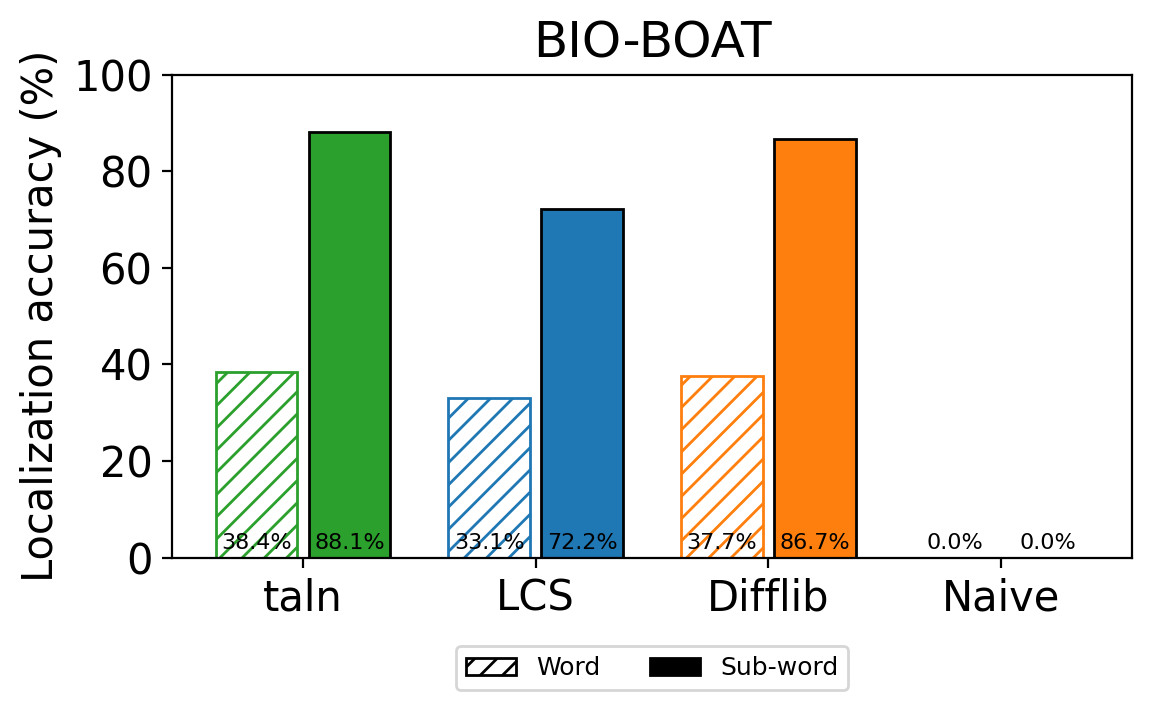

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}


fig, ax = plt.subplots(figsize=(6, 4))

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}
x = np.arange(len(methods))

width = 0.35
gap = 0.025

# --- sub-word (localization accuracy, non-contiguous) -------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = 100 * tdf[f"{m}_loc"].astype(int)
    y_mean = y.mean()

    center = idx + (width/2 + gap)

    ax.bar(
        center, y_mean, width, zorder=0,
        edgecolor="black",
        facecolor=COLORS[m],   # solid method color
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)

# --- word (localization accuracy, non-contiguous) -----------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = 100 * wdf[f"{m}_loc"].astype(int)
    y_mean = y.mean()

    center = idx - (width/2 + gap)

    ax.bar(
        center, y_mean, width, zorder=0,
        edgecolor=COLORS[m],   # colored stripes
        facecolor="white",
        hatch="///",
        linewidth=1,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)

# --- axes / labels -----------------------------------------------------------
ax.set(
    ylabel="Localization accuracy (%)",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0, 100),
    title="BIO-BOAT",
)

# legend
legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]



ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()

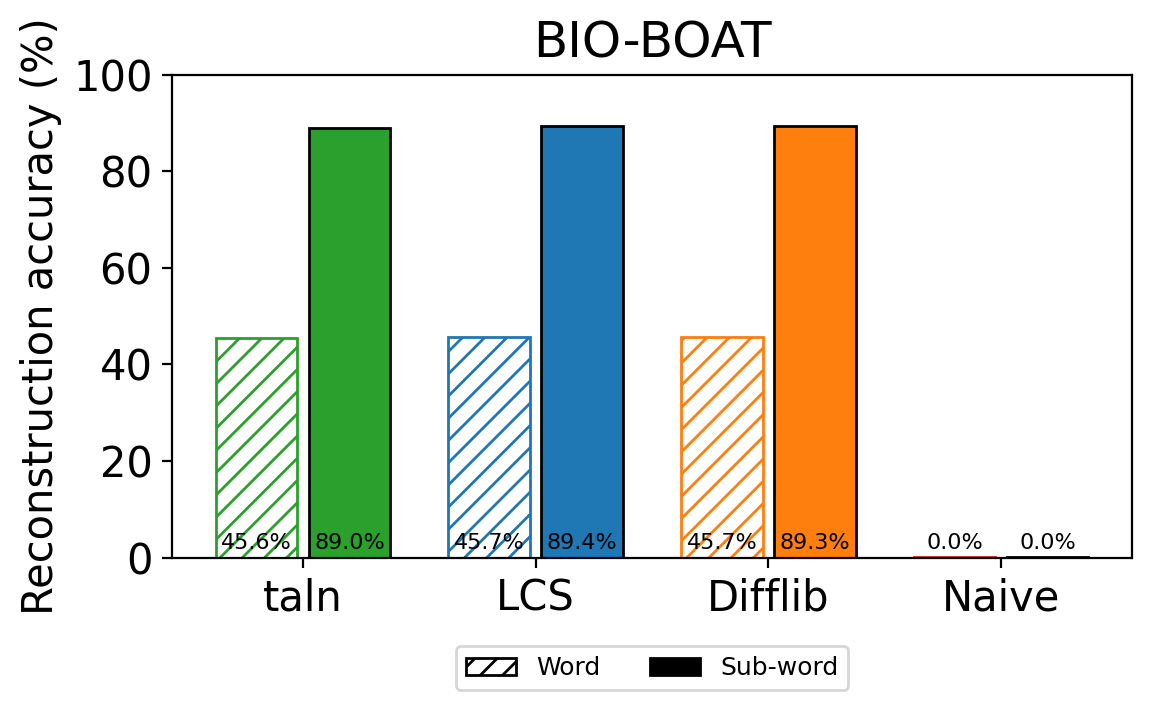

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

fig, ax = plt.subplots(figsize=(6, 4))

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}
x = np.arange(len(methods))

width = 0.35
gap = 0.025

# --- sub-word (reconstruction accuracy, non-contiguous) ----------------------
for idx, (label, m) in enumerate(methods.items()):
    y = 100 * tdf[f"{m}_match"].astype(int)
    y_mean = y.mean()

    center = idx + (width/2 + gap)

    ax.bar(
        center, y_mean, width, zorder=0,
        edgecolor="black",
        facecolor=COLORS[m],
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)

# --- word (reconstruction accuracy, non-contiguous) --------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = 100 * wdf[f"{m}_match"].astype(int)
    y_mean = y.mean()

    center = idx - (width/2 + gap)

    ax.bar(
        center, y_mean, width, zorder=0,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)

ax.set(
    ylabel="Reconstruction accuracy (%)",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0, 100),
    title="BIO-BOAT"
)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()


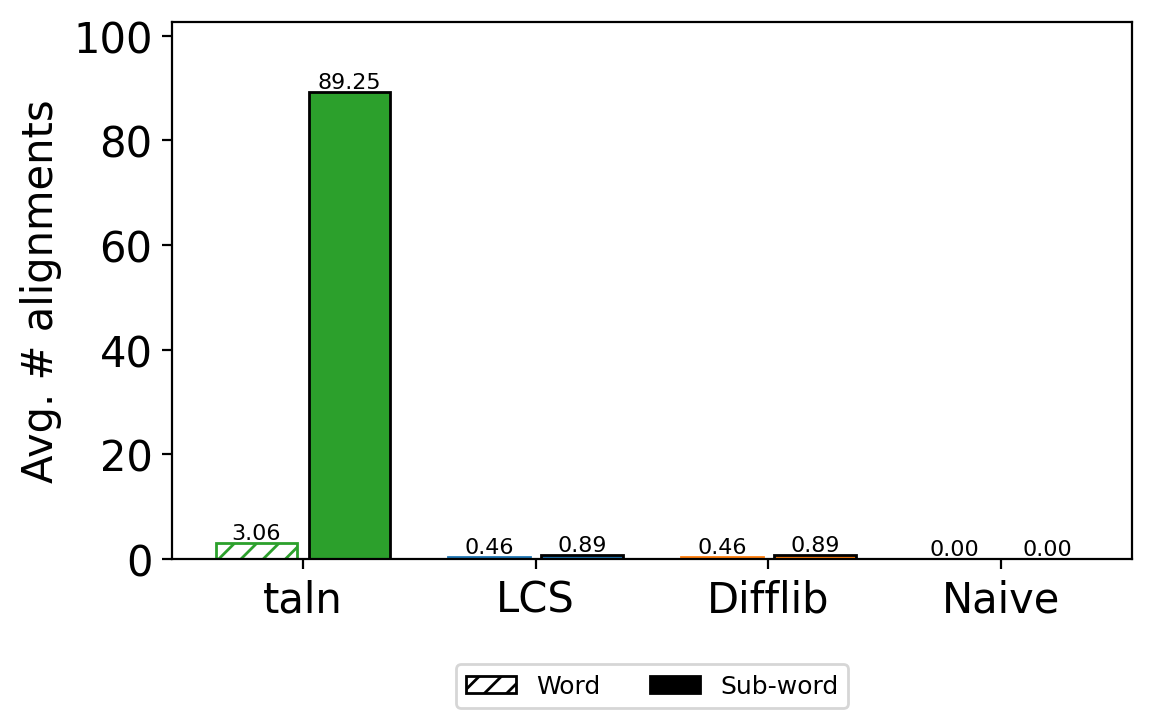

,subword_mean,subword_var,word_mean,word_var
method,,,,
taln,89.249,1.038398e+07,3.055,3604.216
LCS,0.894,9.500000e-02,0.457,0.248
Difflib,0.893,9.600000e-02,0.457,0.248
Naive,0.000,0.000000e+00,0.000,0.000


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Average number of alignments returned per (source,target) for each method.
# Sub-word = tdf (token) and Word = wdf (whitespace).

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}

fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(methods.keys()))
width = 0.35
gap = 0.025

# --- sub-word (tdf) ----------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_naln"].mean())
    center = idx + (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax.text(center, y_mean, f"{y_mean:.2f}", ha="center", va="bottom", fontsize=8)

# --- word (wdf) --------------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_naln"].mean())
    center = idx - (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax.text(center, y_mean, f"{y_mean:.2f}", ha="center", va="bottom", fontsize=8)

ax.set(
    ylabel="Avg. # alignments",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0, max(tdf[[f"{m}_naln" for m in methods.values()]].mean().max(), wdf[[f"{m}_naln" for m in methods.values()]].mean().max()) * 1.15),
)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()

# Variance table
rows = []
for label, m in methods.items():
    rows.append({
        "method": label,
        "subword_mean": float(tdf[f"{m}_naln"].mean()),
        "subword_var": float(tdf[f"{m}_naln"].var()),
        "word_mean": float(wdf[f"{m}_naln"].mean()),
        "word_var": float(wdf[f"{m}_naln"].var()),
    })

pd.DataFrame(rows).set_index("method").round(3)


In [50]:
import numpy as np
import matplotlib.pyplot as plt

# --- pick which accuracy to use ---------------------------------------------
method = "custom_loc"  # or "lcs_loc", "difflib_loc", "naive_loc"

acc_by_tokens = (
    tacc[method]
    .reset_index()
    .rename(columns={"ntks_tgt": "n_tokens", method: "accuracy"})
    .sort_values("n_tokens")
)

# --- plot: tokens vs accuracy -----------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    acc_by_tokens["n_tokens"],
    acc_by_tokens["accuracy"],
    s=20,
    edgecolor="k",
    linewidths=0.25,
    facecolor="#2ca02c",
)

cu_ntks = 300
ax.axvline(cu_ntks, color="grey", linestyle="--")
min_acc = acc_by_tokens.loc[acc_by_tokens["n_tokens"] <= cu_ntks, "accuracy"].min()
ax.axhline(min_acc, color="grey", linestyle="--")

ax.set(
    xlabel="Number of tokens in source",
    ylabel="Accuracy (%)",
    xscale="log",
    ylim=(0, 100),
    title="Non-Contiguous (subword) alignment",
)

# --- right marginal: accuracy distribution -----------------------------------
ax_histy = ax.inset_axes([1.05, 0, 0.25, 1], sharey=ax)

bins = np.arange(0, 101, 5)
ax_histy.hist(
    acc_by_tokens["accuracy"],
    bins=bins,
    orientation="horizontal",
    color="#2ca02c",
    edgecolor="k",
    linewidth=0.25,
)

# same hline on marginal
ax_histy.axhline(min_acc, color="grey", linestyle="--")

ax_histy.tick_params(axis="x", labelbottom=True)
plt.setp(ax_histy.get_yticklabels(), visible=False)

ax_histy.set_xlabel("Count")

plt.show()

KeyError: 'n_tokens'

In [ ]:
tacc.mean(), wacc.mean()

(custom_loc     88.116480
 lcs_loc        64.145409
 difflib_loc    85.561889
 naive_loc       0.000000
 dtype: float64,
 custom_loc     37.939297
 lcs_loc        29.939202
 difflib_loc    36.660807
 naive_loc       0.000000
 dtype: float64)

In [ ]:
import pandas as pd

def compute_stats(texts_w, texts_t):
    chars = texts_w.str.len()
    ws = texts_w.apply(lambda s: len(s.split()))
    toks = texts_t.apply(lambda s: len(tokenize(s)[0]))
    return {
        "Char/Sample": chars.mean(),
        "WS/Sample": ws.mean(),
        "Tok/Sample": toks.mean(),
        "N Samples": texts_w.nunique()
    }

source_stats = compute_stats(
    pd.Series(wdf.source.unique()),
    pd.Series(tdf.source.unique())
)

target_stats = compute_stats(
    pd.Series(wdf.target.unique()),
    pd.Series(tdf.target.unique())
)

table = pd.DataFrame([source_stats, target_stats], index=["source", "ablate_target"])
table = table.round(0)
table

,Char/Sample,WS/Sample,Tok/Sample,N Samples
source,484.0,73.0,106.0,2700
ablate_target,96.0,14.0,20.0,5310


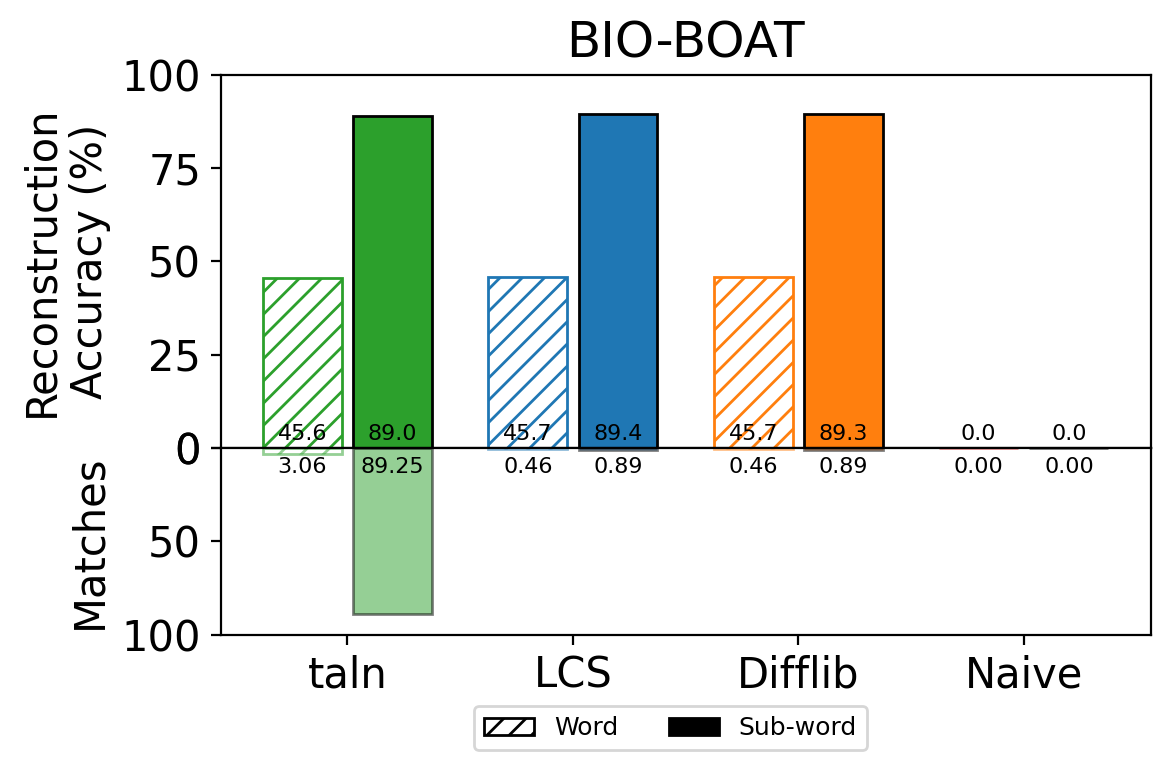

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(6, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# make the panels touch
fig.subplots_adjust(hspace=0)

x = np.arange(len(methods.keys()))
width = 0.35
gap = 0.025

# ===============================
# Top: reconstruction accuracy
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_match"].mean() * 100)
    center = idx + (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_match"].mean() * 100)
    center = idx - (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

ax_top.set(
    ylabel="Reconstruction\nAccuracy (%)",
    ylim=(0, 100),
    title="BIO-BOAT"
)

# hide top x tick labels (shared x-axis)
ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

# ===============================
# Bottom: avg # alignments (flipped)
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_naln"].mean())
    center = idx + (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.2f}", ha="center", va="top", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_naln"].mean())
    center = idx - (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.2f}", ha="center", va="top", fontsize=8)

ax_bot.set(
    ylabel="Matches",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0,100)
)

# flip y-axis so it reads like the barplot is glued upside-down
ax_bot.invert_yaxis()

# remove the touching spines so the join reads as a single panel
# ax_top.spines["bottom"].set_visible(False)

# ax_bot.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

# legend below the bottom x tick labels
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
    fontsize=9,
)

# NOTE: avoid tight_layout() here; it tends to re-introduce hspace.
fig.subplots_adjust(hspace=0, bottom=0.18)

plt.show()


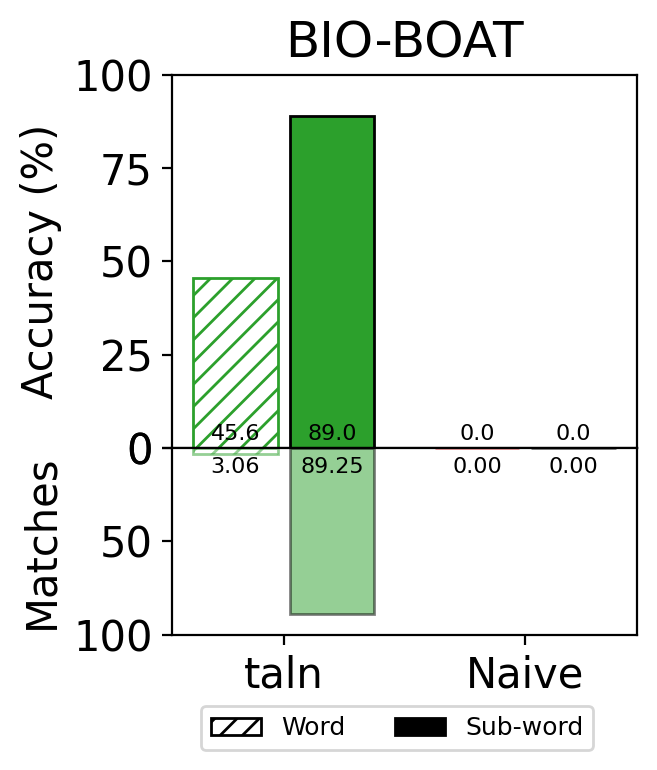

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

methods = {
    "taln": "custom", 
    # "LCS": "lcs", 
    # "Difflib": "difflib", 
    "Naive": "naive"}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(3, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# make the panels touch
fig.subplots_adjust(hspace=0)

x = np.arange(len(methods.keys()))
width = 0.35
gap = 0.025

# ===============================
# Top: reconstruction accuracy
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_match"].mean() * 100)
    center = idx + (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_match"].mean() * 100)
    center = idx - (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

ax_top.set(
    ylabel="Accuracy (%)",
    ylim=(0, 100),
    title="BIO-BOAT"
)

# hide top x tick labels (shared x-axis)
ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

# ===============================
# Bottom: avg # alignments (flipped)
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_naln"].mean())
    center = idx + (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.2f}", ha="center", va="top", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_naln"].mean())
    center = idx - (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.2f}", ha="center", va="top", fontsize=8)

ax_bot.set(
    ylabel="Matches",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0,100)
)

# flip y-axis so it reads like the barplot is glued upside-down
ax_bot.invert_yaxis()

# remove the touching spines so the join reads as a single panel
# ax_top.spines["bottom"].set_visible(False)

# ax_bot.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

# legend below the bottom x tick labels
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
    fontsize=9,
)

# NOTE: avoid tight_layout() here; it tends to re-introduce hspace.
fig.subplots_adjust(hspace=0, bottom=0.18)

plt.show()


In [52]:
# --- BioBOAT dataset table (non-contiguous / ablated) -------------------------
# Compute stats from the already-ablated frames used in this notebook.

from taln.taln_aln import tokenize


def ws_len(s):
    return len(str(s).split())


def tok_len(s, ttype="token"):
    toks, _ = tokenize(str(s), ttype)
    return len(toks)


bio_nontig = tdf.reset_index(drop=True).copy()

# Use full-match alignment counts (custom_naln) to match the figures
n_align = bio_nontig["custom_naln"]

src = bio_nontig["source"].astype(str)
tgt = bio_nontig["ablate_target"].astype(str)

row = {
    "n_pairs": int(bio_nontig.shape[0]),
    "n_zero_align_tok": int((n_align == 0).sum()),
    # mean over ALL pairs (including zeros) to match the figures
    "mean_align_tok": float(n_align.mean()),
    "mean_source_chars": float(src.str.len().mean()),
    "mean_source_ws": float(src.apply(ws_len).mean()),
    "mean_source_tok": float(src.apply(tok_len).mean()),
    "mean_target_chars": float(tgt.str.len().mean()),
    "mean_target_ws": float(tgt.apply(ws_len).mean()),
    "mean_target_tok": float(tgt.apply(tok_len).mean()),
}

bio_tbl = pd.DataFrame({"noncontiguous_bio": row}).T

cols = [
    "n_pairs",
    "n_zero_align_tok",
    "mean_align_tok",
    "mean_source_chars",
    "mean_source_ws",
    "mean_source_tok",
    "mean_target_chars",
    "mean_target_ws",
    "mean_target_tok",
]

bio_tbl = bio_tbl[cols]

display(
    bio_tbl.round(
        {
            "n_pairs": 0,
            "n_zero_align_tok": 0,
            "mean_align_tok": 3,
            "mean_source_chars": 1,
            "mean_source_ws": 1,
            "mean_source_tok": 1,
            "mean_target_chars": 1,
            "mean_target_ws": 1,
            "mean_target_tok": 1,
        }
    )
)



,n_pairs,n_zero_align_tok,mean_align_tok,mean_source_chars,mean_source_ws,mean_source_tok,mean_target_chars,mean_target_ws,mean_target_tok
noncontiguous_bio,5316.0,584.0,89.249,606.8,91.1,131.9,90.2,13.3,18.4
